In [1]:
import torch
from train import train
from lofi_model import LofiModel
from dataset import MidiDataset
import pretty_midi
import numpy as np
from config import *
print(torch.__version__)
print(torch.version.cuda)

c:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\venv\Lib\site-packages\pretty_midi\instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2.7.1+cu118
11.8


In [2]:
model = LofiModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model.load_state_dict(torch.load("./saved_models/progress/lofi-model_epoch158.pth"))
model.to(device)
model.eval()

LofiModel(
  (encoder): ImprovedEncoder(
    (lstm): LSTM(76, 512, num_layers=2, batch_first=True, dropout=0.2)
    (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (fc_mean): Linear(in_features=512, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=64, bias=True)
  )
  (decoder): ImprovedDecoder(
    (lstm): LSTM(76, 512, num_layers=2, batch_first=True, dropout=0.2)
    (fc_z_to_hidden): Linear(in_features=64, out_features=1024, bias=True)
    (fc_z_to_cell): Linear(in_features=64, out_features=1024, bias=True)
    (fc_out): Linear(in_features=512, out_features=76, bias=True)
    (fc_residual): Linear(in_features=76, out_features=76, bias=True)
    (batch_norm_out): BatchNorm1d(76, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

## Reconstruction

In [3]:
# dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\golden_dataset\all_songs"
dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\transformed_dataset_3_imnstrumenty"

dataset = MidiDataset(dataset_dir, verbose=True)

Processing file: 00081fefb9485dc2ef642cc300390813
Original sequence:


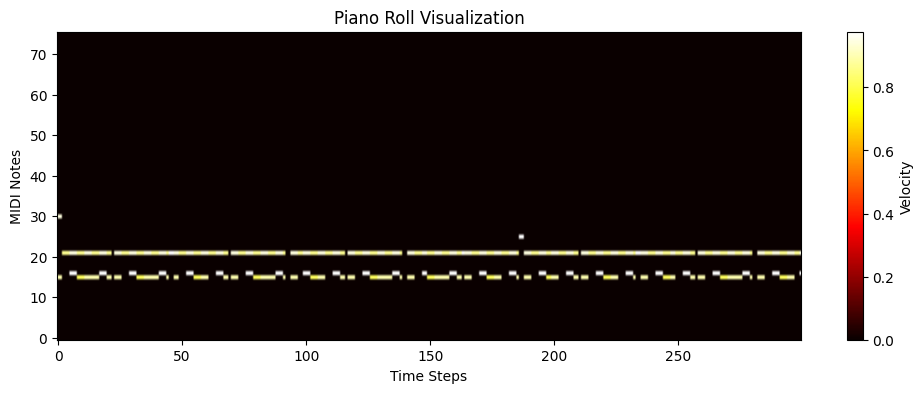

Reconstruction:


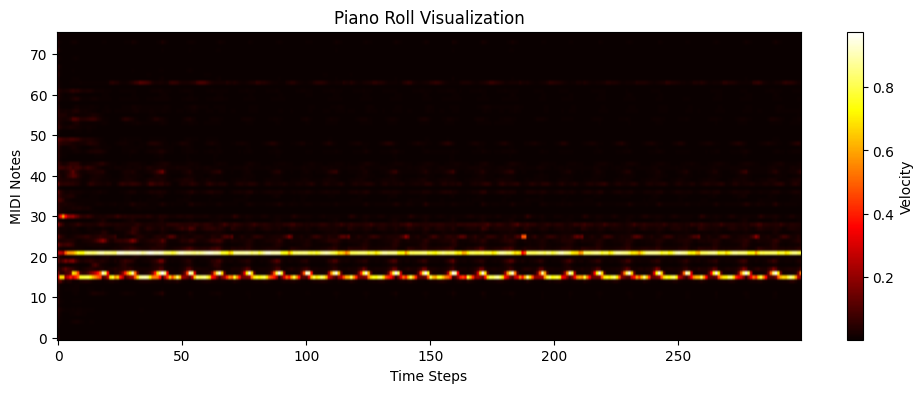

________________________________________________________________________________________________________________________

Processing file: 000c923c18c62332503050809ea3eb8f
Original sequence:


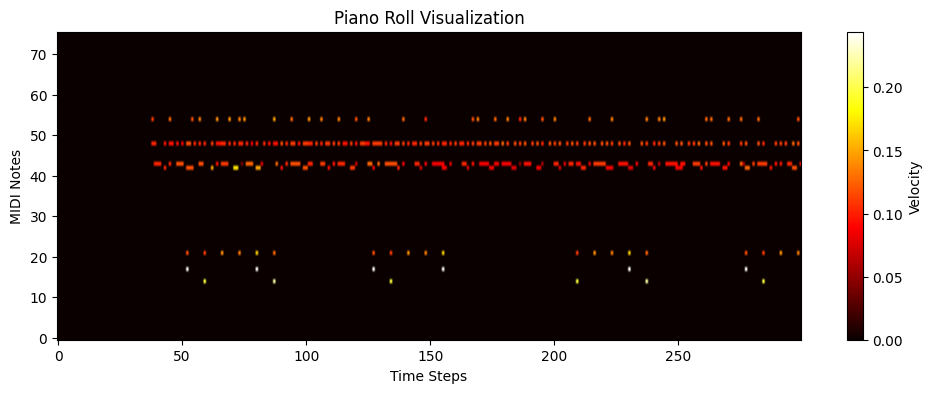

Reconstruction:


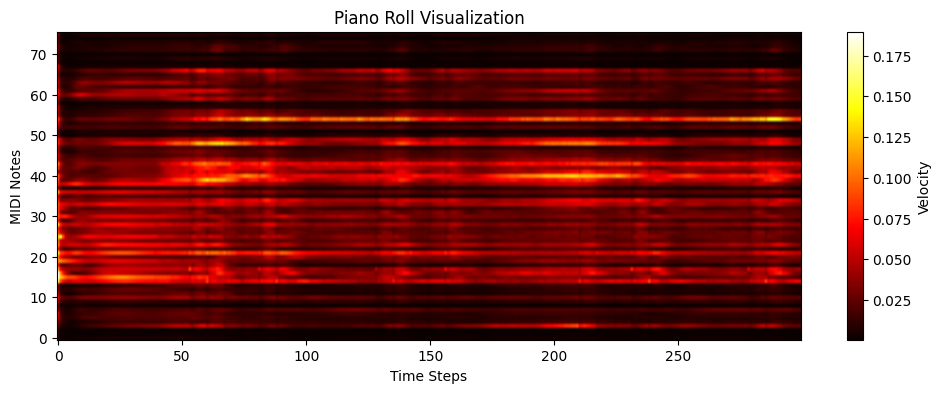

________________________________________________________________________________________________________________________

Processing file: 001aed0e250bcca69cd78bb30c77cf9e
Original sequence:


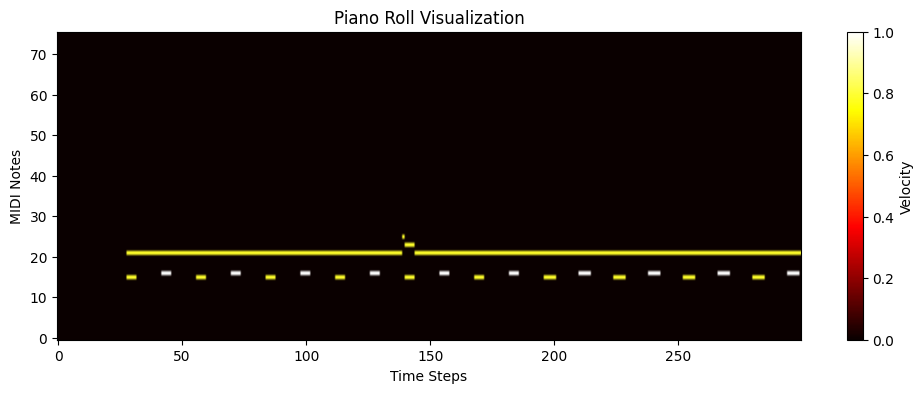

Reconstruction:


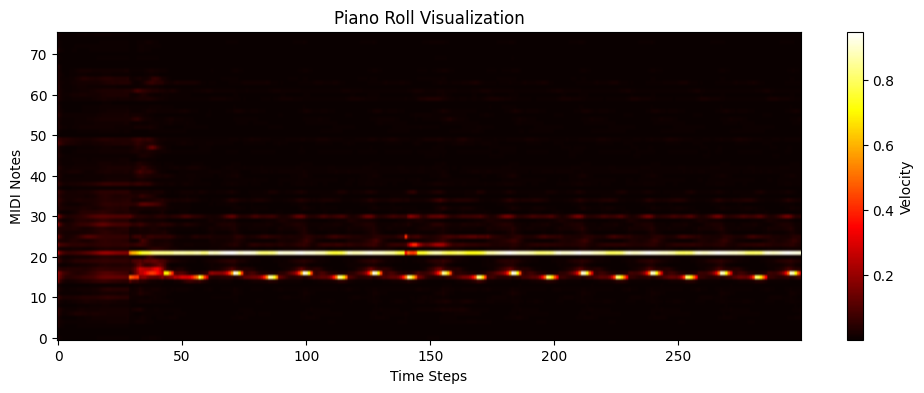

________________________________________________________________________________________________________________________

Processing file: 00231887ed5201b0e9c2d850c38b1c16
Original sequence:


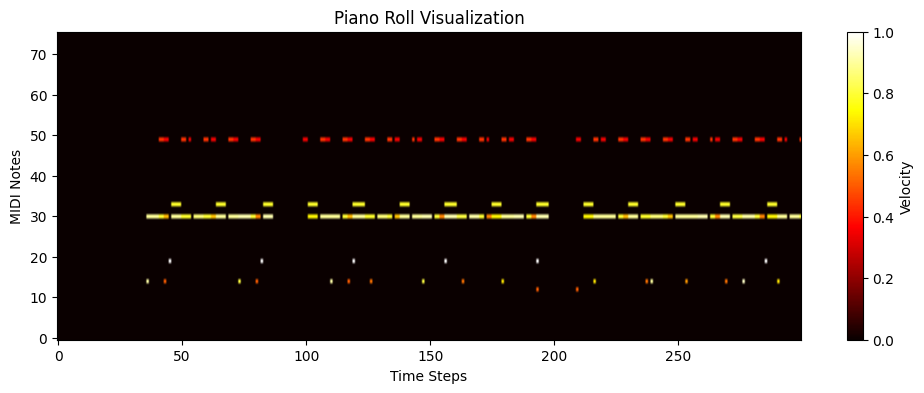

Reconstruction:


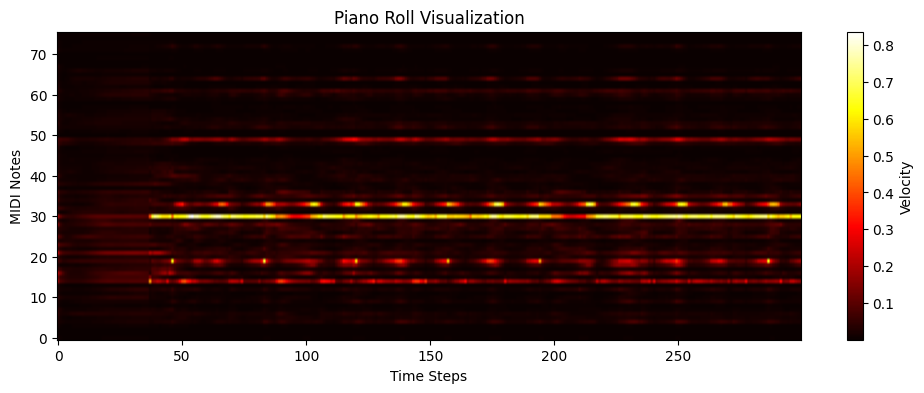

________________________________________________________________________________________________________________________

Processing file: 00369e2996619a1037bfa5d33b9a3dda
Original sequence:


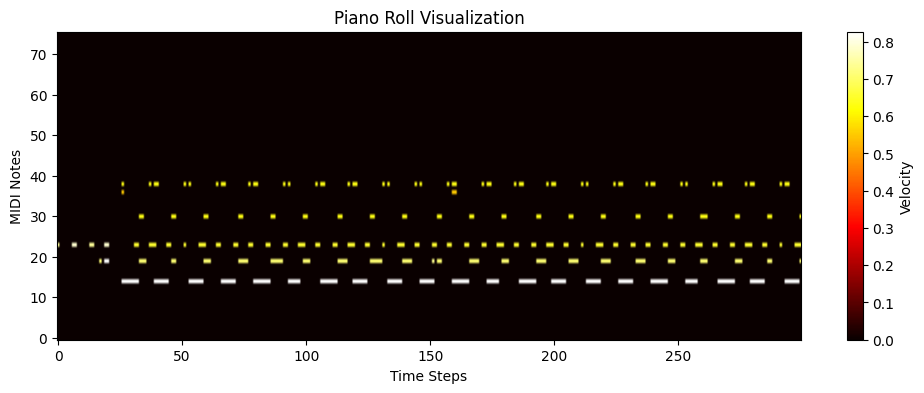

Reconstruction:


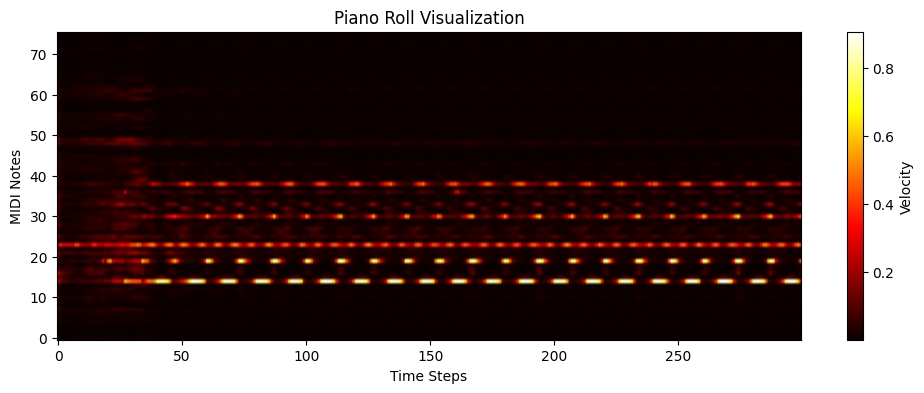

________________________________________________________________________________________________________________________



In [4]:
for i in range(5):
    original_sequence_tensor, original_length_val, filename = dataset[i]
    print(f"Processing file: {filename}")
    print(f"Original sequence:")
    dataset.visualize_midi(original_sequence_tensor)
    print(f"Reconstruction:")
    reconstructions = model.reconstruct(original_sequence_tensor, original_length_val)
    print(60*"__"+"\n")

In [5]:
original_sequence_tensor

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])